In [13]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=32, batch_size=128)

In [6]:
def train_model(optimizer_name):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = nn.Sequential(

        nn.Conv2d(3, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),

        nn.Linear(64 * 8 * 8, 128),
        nn.ReLU(),

        nn.Linear(128, NUM_CLASSES)

    ).to(device)

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.001
        )

    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=0.001,
            momentum=0.9
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=0.001
        )

    epochs = 5

    losses = []
    accuracies = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss

        losses.append(epoch_loss)

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                predictions = outputs.argmax(dim=1)

                correct += (
                    predictions == labels
                ).sum().item()

                total += labels.size(0)

        accuracy = 100 * correct / total

        accuracies.append(accuracy)

        print(
            f"{optimizer_name} | "
            f"Epoch {epoch+1} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Validation Accuracy: {accuracy:.2f}%"
        )

    return model, losses, accuracies

In [7]:
def metrics(model, test_loader, device):

    model.eval()

    cm = np.zeros((43, 43), dtype=int)

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predictions = torch.max(outputs, 1)

            for label, prediction in zip(labels, predictions):

                cm[label.item(), prediction.item()] += 1

    np.set_printoptions(threshold=np.inf)

    print("Matriz de Confusão:")
    print(cm)

    acc_class = [0 for _ in GTSRB_CLASSES]

    print("\nAcurácia por classe:")

    for i in range(43):

        total_class = np.sum(cm[i, :])

        if total_class > 0:

            acc = 100 * (cm[i, i] / total_class)

        else:

            acc = 0

        acc_class[i] = acc

        print(f"Classe {i}: {acc:.2f}%")

    worst_class = acc_class.index(min(acc_class))
    best_class = acc_class.index(max(acc_class))

    print(
        f"\nWorst class: {worst_class} "
        f"- {min(acc_class):.2f}%"
    )

    print(
        f"Best class: {best_class} "
        f"- {max(acc_class):.2f}%"
    )

    return cm, acc_class

In [14]:
def generate_predictions(model):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.eval()

    predictions_list = []

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            predictions_list.extend(
                predictions.cpu().numpy()
            )
        metrics(model, test_loader, device)
    return predictions_list

In [9]:
model_sgd, losses_sgd, accs_sgd = train_model("SGD")

c:\Users\rafae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


SGD | Epoch 1 | Loss: 594.5502 | Validation Accuracy: 16.82%
SGD | Epoch 2 | Loss: 542.2253 | Validation Accuracy: 24.98%
SGD | Epoch 3 | Loss: 500.8895 | Validation Accuracy: 30.27%
SGD | Epoch 4 | Loss: 465.5552 | Validation Accuracy: 35.15%
SGD | Epoch 5 | Loss: 434.7163 | Validation Accuracy: 38.36%


In [10]:
model_momentum, losses_momentum, accs_momentum = train_model("Momentum")

Momentum | Epoch 1 | Loss: 477.3124 | Validation Accuracy: 46.17%
Momentum | Epoch 2 | Loss: 286.2571 | Validation Accuracy: 66.22%
Momentum | Epoch 3 | Loss: 184.0750 | Validation Accuracy: 81.57%
Momentum | Epoch 4 | Loss: 126.1647 | Validation Accuracy: 87.93%
Momentum | Epoch 5 | Loss: 91.3320 | Validation Accuracy: 91.52%


In [11]:
model_adam, losses_adam, accs_adam = train_model("Adam")

Adam | Epoch 1 | Loss: 208.2355 | Validation Accuracy: 91.35%
Adam | Epoch 2 | Loss: 37.5749 | Validation Accuracy: 96.28%
Adam | Epoch 3 | Loss: 16.0165 | Validation Accuracy: 98.33%
Adam | Epoch 4 | Loss: 9.9824 | Validation Accuracy: 98.57%
Adam | Epoch 5 | Loss: 5.6858 | Validation Accuracy: 98.76%


In [15]:
print('Metrics for sgd')
y_pred_sgd = generate_predictions(model_sgd)

Metrics for sgd


c:\Users\rafae\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Matriz de Confusão:
[[  0  36  11   0   7   0   0   0   0   0   0   0   0   2   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   4   0   0   0   0]
 [  0 478 120   1  47  31   0   0   7   1  20   0   7   6   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   2   0   0   0   0]
 [  0 215 175  18 105  51   0   0  16   0 119   0  33  17   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   1   0   0   0   0]
 [  0  90  24  22  51  95   0   0  17   0 118   0  18   3   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  12   0   0   0   0]
 [  0 114  58  22  62  59   0   0  51   0 258   0  24   9   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   3   0   0   0   0]
 [  0 109 148   0 110 109   0   0   6   0 126   0  19   1   0   0   0   0
    0   0  

In [16]:
print('Metrics for momentum')
y_pred_momentum = generate_predictions(model_momentum)

Metrics for momentum
Matriz de Confusão:
[[  3  56   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0 658  27   3   4   3   1   2  20   0   0   0   0   2   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  8  66 596   7   7  46   0   0   2   0   0   0   0   2   0  15   0   0
    0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0  22  26 233   4 148   0   5   4   1   2   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   2   0   0   0   0   0   2   0   0   0   0
    0   0   0   0   0   0   0]
 [  1  55  21  15 494  43   0   3  22   0   0   0   0   3   0   1   0   0
    0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0  30  57   2  12 479   0   8  34   0   4   0   0   0   0   

In [17]:
print('Metrics for adam')
y_pred_adam = generate_predictions(model_adam)

save_predictions(
    y_pred_adam,
    "results/predicoes_batchnorm_adam.csv",
    experiment_name="CNN BatchNorm Adam"
)

Metrics for adam
Matriz de Confusão:
[[ 24  33   0   0   0   0   0   0   3   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0 696   6   0  12   0   0   0   4   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  2  23 719   0   3   0   0   0   1   2   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   7   9 390   0  31   2   1   2   2   0   0   0   1   0   0   1   0
    0   0   1   0   0   1   0   0   0   0   0   0   1   1   0   0   0   0
    0   0   0   0   0   0   0]
 [  0  14   0   0 625   3   0   3   4   3   0   0   1   0   1   0   0   0
    0   0   0   0   0   0   0   0   0   0   1   0   0   0   5   0   0   0
    0   0   0   0   0   0   0]
 [  0  25  32   3  12 508   0   6  34   0   0   0   0   1   0   0   

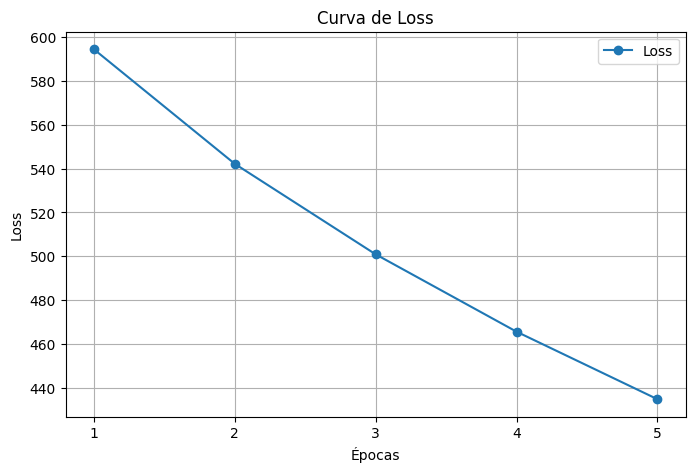

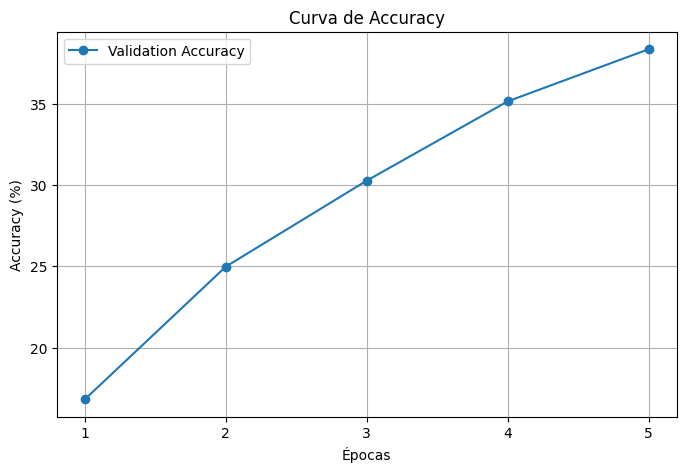

In [18]:
epochs_range = range(1, 6)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    losses_sgd,
    marker='o',
    label='Loss'
)

plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    accs_sgd,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()

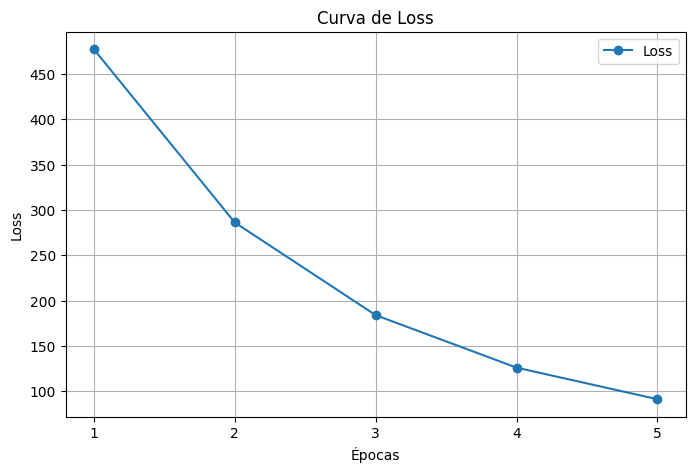

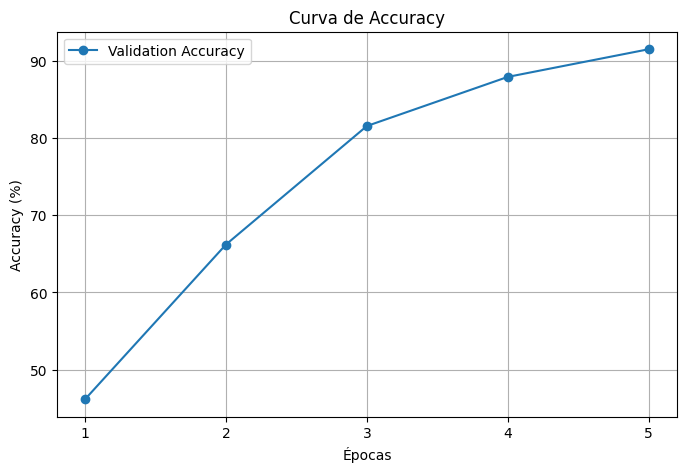

In [19]:
epochs_range = range(1, 6)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    losses_momentum,
    marker='o',
    label='Loss'
)

plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    accs_momentum,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()

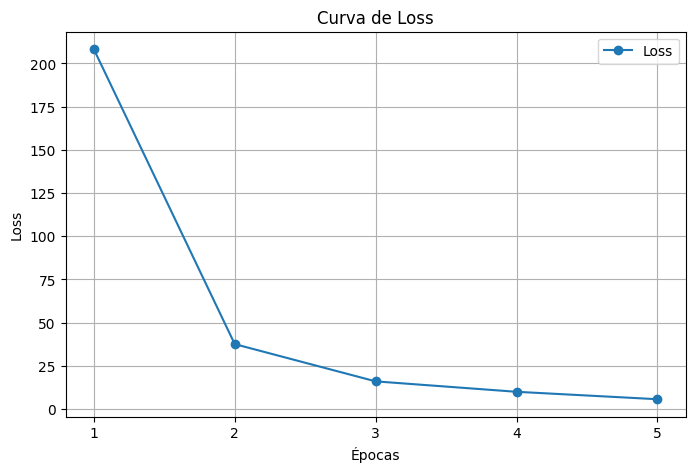

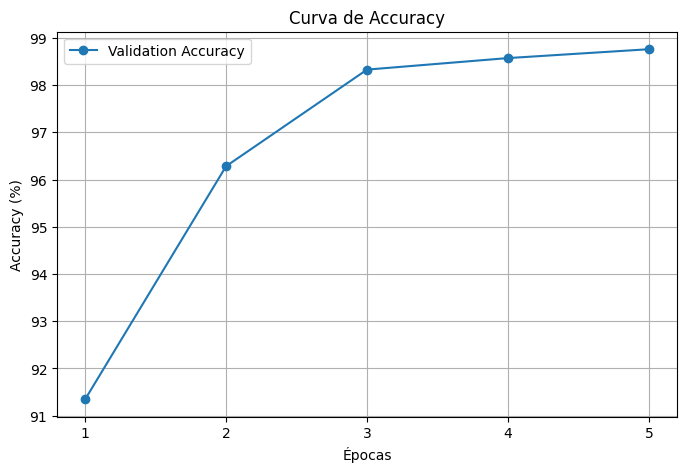

In [20]:
epochs_range = range(1, 6)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    losses_adam,
    marker='o',
    label='Loss'
)

plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    accs_adam,
    marker='o',
    label='Validation Accuracy'
)

plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (%)')

plt.xticks(epochs_range)

plt.grid(True)

plt.legend()

plt.show()